In [32]:
import polars as pl
import os
import json
from pathlib import Path

NOTEBOOK_DIR = Path(os.path.abspath('')).resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]  # Fast_Data_Discovery
PAPER_ROOT = PROJECT_ROOT.parent / 'Matryoshka'

exp_path = NOTEBOOK_DIR / 'logs'
base_scores = pl.read_csv(PROJECT_ROOT / 'experiments' / 'base_tables' / 'base_simple_scores.csv').rename({'': 'table'})
aug_scores = pl.read_csv(exp_path / 'simple_results.csv').rename({'': 'experiment'})

exp_dir = os.listdir(exp_path)
runtime_res = {}
for exp in exp_dir:
    if not os.path.isdir(exp_path / exp):
        continue
    comb_log = exp_path / exp / f'{exp}.log'
    with open(comb_log) as f:
        lines = f.readlines()
    for i in range(len(lines)):
        lines[i] = json.loads(lines[i])
    df = pl.from_records(lines, orient='col')
    runtime = df.select(pl.col('runtime').sum()).to_series()[0]
    runtime_res[exp] = runtime
runtime_df = pl.from_dicts([{'experiment': k, 'runtime': v} for k, v in runtime_res.items()])
aug_scores = aug_scores.join(runtime_df, left_on='experiment', right_on='experiment', how='left')
aug_scores = aug_scores.with_columns(
    pl.col('experiment').str.split('_').list.to_struct(upper_bound=3, fields=['lake', 'table', 'task', 'threshold']).struct.unnest()
)
aug_scores = aug_scores.join(base_scores, on='table', how='left', suffix='_base')

aug_scores = aug_scores.with_columns((pl.col('rmse_base').fill_null(0) + pl.col('f1_weighted_base').fill_null(0)).round(3).alias('score_base'))
aug_scores = aug_scores.with_columns((pl.col('rmse').fill_null(0) + pl.col('f1_weighted').fill_null(0)).round(3).alias('score'))
aug_scores = aug_scores.with_columns(
    pl.when(pl.col('rmse').is_not_null())
    .then(pl.lit('rmse'))
    .otherwise(pl.lit('f1'))
    .alias('metric')
)
# Create base rows for each unique (lake, table) combination
base_rows = (
    aug_scores
    .unique(subset=['lake', 'table'])
    .with_columns([
        pl.lit('base').alias('algorithm'),
        pl.col('score_base').alias('score'),
        pl.col('rmse_base').alias('rmse'),
        pl.col('f1_weighted_base').alias('f1'),
        pl.lit(0.0).alias('runtime'),
        (pl.col('lake') + '_' + pl.col('table') + '_base').alias('experiment')
    ])
    .select(aug_scores.columns)
)
aug_scores = pl.concat([aug_scores, base_rows])
aug_scores = aug_scores.with_columns(
    pl.when(pl.col('table') == 'pageviews')
    .then((pl.col('score')/1e6).round(3))
    .otherwise(pl.col('score'))
    .alias('score')
)

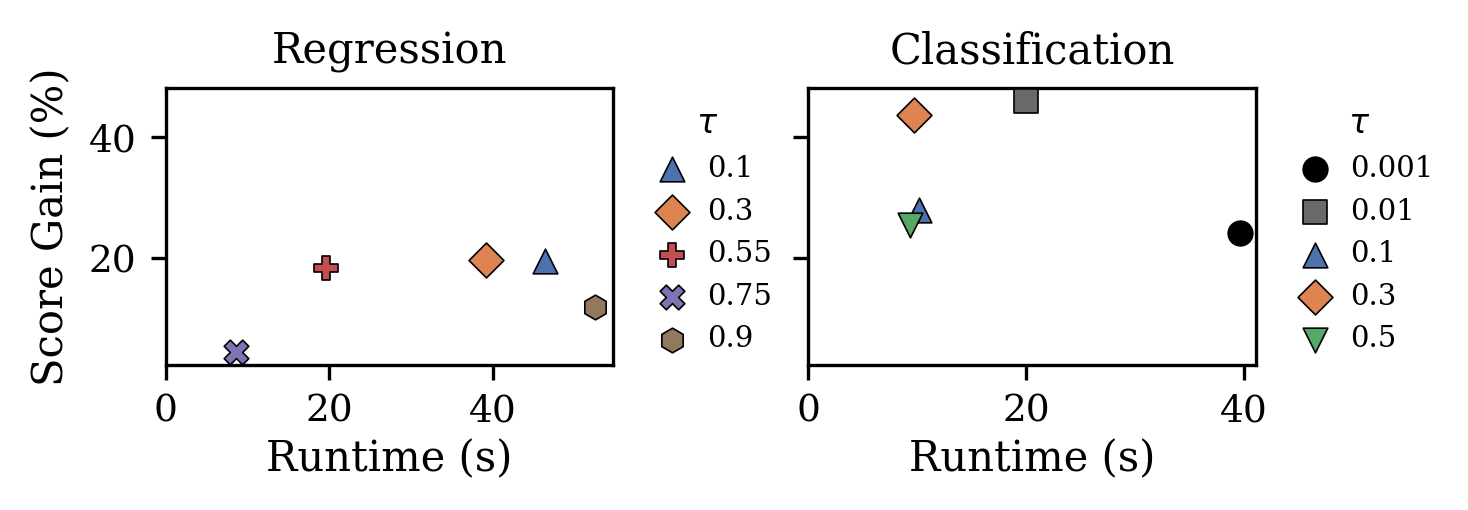

In [33]:
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, str(PROJECT_ROOT / 'experiments'))
import plots_style
plots_style.apply_style()

# Filter out base rows
data = aug_scores.filter(pl.col('threshold').is_not_null())

# Scale score_base for pageviews
data = data.with_columns(
    pl.when(pl.col('table') == 'pageviews')
    .then(pl.col('score_base') / 1e6)
    .otherwise(pl.col('score_base'))
    .alias('base_score')
)

# Relative improvement (direction-aware)
data = data.with_columns(
    pl.when(pl.col('metric') == 'rmse')
    .then((pl.col('base_score') - pl.col('score')) / pl.col('base_score'))
    .otherwise((pl.col('score') - pl.col('base_score')) / pl.col('base_score'))
    .alias('rel_improvement')
)

# Split by task type
regression_tables = data.filter(pl.col('task') == 'regression')
classification_tables = data.filter(pl.col('task') == 'classification')

# Aggregate per threshold within each task type
def agg_by_threshold(df):
    return (df.group_by('threshold').agg([
        pl.col('rel_improvement').mean().alias('mean_improvement'),
        pl.col('runtime').mean().alias('mean_runtime'),
    ]).with_columns(pl.col('threshold').cast(pl.Float64).alias('thr_num'))
    .sort('thr_num'))

agg_reg = agg_by_threshold(regression_tables)
agg_cls = agg_by_threshold(classification_tables)

# Marker / color maps for thresholds
all_thresholds = sorted(data['threshold'].unique().to_list(), key=float)
markers_list = ['o', 's', '^', 'D', 'v', 'P', 'X', 'h']
colors_list = ['black', 'dimgray', '#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3', '#937860']
marker_map = {t: markers_list[i % len(markers_list)] for i, t in enumerate(all_thresholds)}
color_map  = {t: colors_list[i % len(colors_list)] for i, t in enumerate(all_thresholds)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(4.8, 1.6), sharey=True)

for agg_df, ax, title in [(agg_reg, ax1, 'Regression'), (agg_cls, ax2, 'Classification')]:
    for row in agg_df.iter_rows(named=True):
        t = row['threshold']
        ax.scatter(row['mean_runtime'], row['mean_improvement'] * 100,
                   marker=marker_map[t], color=color_map[t],
                   label=t, s=35, zorder=3, edgecolors='black', linewidths=0.4)
    ax.set_xlim(left=0)
    ax.set_xlabel('Runtime (s)', labelpad=2)
    ax.set_title(title, fontsize=10)
    ax.legend(title='$\\tau$', ncol=1, fontsize=7, title_fontsize=8,
              handletextpad=0.2, borderpad=0.2, columnspacing=0.6,
              loc='upper left', bbox_to_anchor=(1.02, 1.0))

ax1.set_ylabel('Score Gain (%)')

plt.tight_layout(pad=0.3)
plt.savefig(PAPER_ROOT / 'figures' / 'corr_threshold_ablation.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

In [34]:
# Generate TikZ scatter plots (regression + classification side-by-side)
data = aug_scores.filter(pl.col('threshold').is_not_null())

# Scale score_base for pageviews
data = data.with_columns(
    pl.when(pl.col('table') == 'pageviews')
    .then(pl.col('score_base') / 1e6)
    .otherwise(pl.col('score_base'))
    .alias('base_score')
)

data = data.with_columns(
    pl.when(pl.col('metric') == 'rmse')
    .then((pl.col('base_score') - pl.col('score')) / pl.col('base_score'))
    .otherwise((pl.col('score') - pl.col('base_score')) / pl.col('base_score'))
    .alias('rel_improvement')
)

def agg_by_threshold(df):
    return (df.group_by('threshold').agg([
        pl.col('rel_improvement').mean().alias('mean_improvement'),
        pl.col('runtime').mean().alias('mean_runtime'),
    ]).with_columns(pl.col('threshold').cast(pl.Float64).alias('thr_num'))
    .sort('thr_num'))

agg_reg = agg_by_threshold(data.filter(pl.col('task') == 'regression'))
agg_cls = agg_by_threshold(data.filter(pl.col('task') == 'classification'))

# All unique thresholds across both panels (sorted numerically)
all_thresholds = sorted(data['threshold'].unique().to_list(), key=float)

# Marker + color definitions per threshold
marker_map = {
    '0.001': '*',        '0.01': 'square*',   '0.1': 'triangle*',
    '0.3': 'diamond*',   '0.5': 'pentagon*',   '0.55': 'otimes*',
    '0.75': 'star',      '0.9': 'halfsquare*',
}
color_defs = {
    '0.001': ('corrA', '0,0,0'),
    '0.01':  ('corrB', '105,105,105'),
    '0.1':   ('corrC', '76,114,176'),
    '0.3':   ('corrD', '221,132,82'),
    '0.5':   ('corrE', '85,168,104'),
    '0.55':  ('corrF', '196,78,82'),
    '0.75':  ('corrG', '129,114,179'),
    '0.9':   ('corrH', '147,120,96'),
}

tikz = []
# Color definitions
for t in all_thresholds:
    name, rgb = color_defs[t]
    tikz.append(f"\\definecolor{{{name}}}{{RGB}}{{{rgb}}}")

tikz.append("")

# Helper to build one axis environment
def build_axis(agg_df, title, ylabel=True, name=None, at=None):
    lines = []
    lines.append(r"\begin{axis}[")
    if name:
        lines.append(f"  name={name},")
    if at:
        lines.append(f"  at={{({at}.outer east)}},")
        lines.append(f"  anchor=outer west,")
        lines.append(f"  xshift=0.3cm,")
    lines.append(r"  width=1.55in,")
    lines.append(r"  height=1.2in,")
    lines.append(r"  xlabel={Runtime (s)},")
    if ylabel:
        lines.append(r"  ylabel={Score Gain (\%)},")
    else:
        lines.append(r"  yticklabels={},")
    lines.append(f"  title={{{title}}},")
    lines.append(r"  title style={font=\small},")
    lines.append(r"  xmin=0,")
    lines.append(r"  ymin=0,")
    lines.append(r"  x label style={font=\small},")
    lines.append(r"  y label style={font=\small},")
    lines.append(r"  x tick label style={font=\scriptsize},")
    lines.append(r"  y tick label style={font=\scriptsize},")
    lines.append(r"  legend style={font=\scriptsize, at={(1.02,0.5)}, anchor=west, draw=none, row sep=-2pt},")
    lines.append(r"  legend cell align={left},")
    lines.append(r"  axis lines=left,")
    lines.append(r"  clip=false,")
    lines.append(r"]")

    for row in agg_df.iter_rows(named=True):
        t = row['threshold']
        x = row['mean_runtime']
        y = row['mean_improvement'] * 100
        mk = marker_map.get(t, '*')
        cname = color_defs[t][0]
        lines.append(f"\\addplot[only marks, mark={mk}, mark size=2pt, {cname}, mark options={{draw=black, line width=0.3pt}}]")
        lines.append(f"  coordinates {{({x:.1f},{y:.1f})}};")
        lines.append(f"\\addlegendentry{{${float(t)}$}}")

    lines.append(r"\end{axis}")
    return lines

tikz.append(r"\begin{tikzpicture}")
# Left panel: Regression
tikz.extend(build_axis(agg_reg, 'Regression', ylabel=True, name='left'))
tikz.append("")
# Right panel: Classification
tikz.extend(build_axis(agg_cls, 'Classification', ylabel=False, name='right', at='left'))
tikz.append(r"\end{tikzpicture}")

tikz_code = "\n".join(tikz)
out_path = PAPER_ROOT / 'figures' / 'corr_threshold_ablation.tex'
out_path.write_text(tikz_code)
print(f"Written to {out_path}")
print()
print(tikz_code)

Written to /home/fedor/Matryoshka/figures/corr_threshold_ablation.tex

\definecolor{corrA}{RGB}{0,0,0}
\definecolor{corrB}{RGB}{105,105,105}
\definecolor{corrC}{RGB}{76,114,176}
\definecolor{corrD}{RGB}{221,132,82}
\definecolor{corrE}{RGB}{85,168,104}
\definecolor{corrF}{RGB}{196,78,82}
\definecolor{corrG}{RGB}{129,114,179}
\definecolor{corrH}{RGB}{147,120,96}

\begin{tikzpicture}
\begin{axis}[
  name=left,
  width=1.55in,
  height=1.2in,
  xlabel={Runtime (s)},
  ylabel={Score Gain (\%)},
  title={Regression},
  title style={font=\small},
  xmin=0,
  ymin=0,
  x label style={font=\small},
  y label style={font=\small},
  x tick label style={font=\scriptsize},
  y tick label style={font=\scriptsize},
  legend style={font=\scriptsize, at={(1.02,0.5)}, anchor=west, draw=none, row sep=-2pt},
  legend cell align={left},
  axis lines=left,
  clip=false,
]
\addplot[only marks, mark=triangle*, mark size=2pt, corrC, mark options={draw=black, line width=0.3pt}]
  coordinates {(46.3,19.6)};
\add